## Class balance

In [1]:
import h5py
import numpy as np
from pathlib import Path

DATA_DIR = Path("../data/raw")  # notebook is inside notebooks/, so we go up one level

with h5py.File(DATA_DIR / "camelyonpatch_level_2_split_train_y.h5", "r") as f:
    labels = f["y"][:].reshape(-1)  # flatten (N, 1, 1, 1) to (N,)

total = len(labels)
positive = int(labels.sum())
negative = total - positive

print(f"total patches: {total}")
print(f"tumor (label=1): {positive} ({positive/total*100:.1f}%)")
print(f"no tumor (label=0): {negative} ({negative/total*100:.1f}%)")

total patches: 262144
tumor (label=1): 131072 (50.0%)
no tumor (label=0): 131072 (50.0%)


## Visualize sample patches

Matplotlib is building the font cache; this may take a moment.


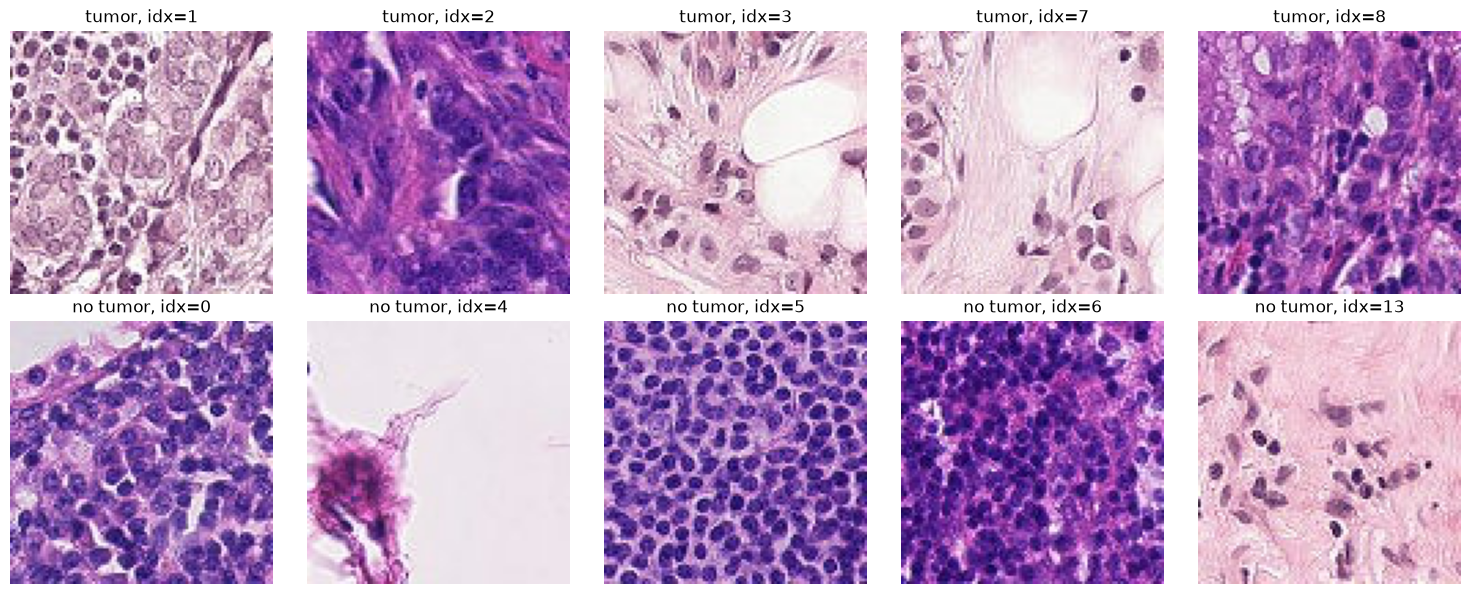

In [2]:
import matplotlib.pyplot as plt

with h5py.File(DATA_DIR / "camelyonpatch_level_2_split_train_x.h5", "r") as f:
    images = f["x"]

    tumor_indices = np.where(labels == 1)[0][:5]
    normal_indices = np.where(labels == 0)[0][:5]

    fig, axes = plt.subplots(2, 5, figsize=(15, 6))

    for col, idx in enumerate(tumor_indices):
        axes[0, col].imshow(images[idx])
        axes[0, col].set_title(f"tumor, idx={idx}")
        axes[0, col].axis("off")

    for col, idx in enumerate(normal_indices):
        axes[1, col].imshow(images[idx])
        axes[1, col].set_title(f"no tumor, idx={idx}")
        axes[1, col].axis("off")

    plt.tight_layout()
    plt.savefig("../docs/sample_patches.png", dpi=100)
    plt.show()

#### visually, tumor vs non-tumor patches are not easily distinguishable by eye at this resolution; the model needs to learn features humans don't naturally pick up on directly.👆👆👆👆🔼

## Stain variation across slides

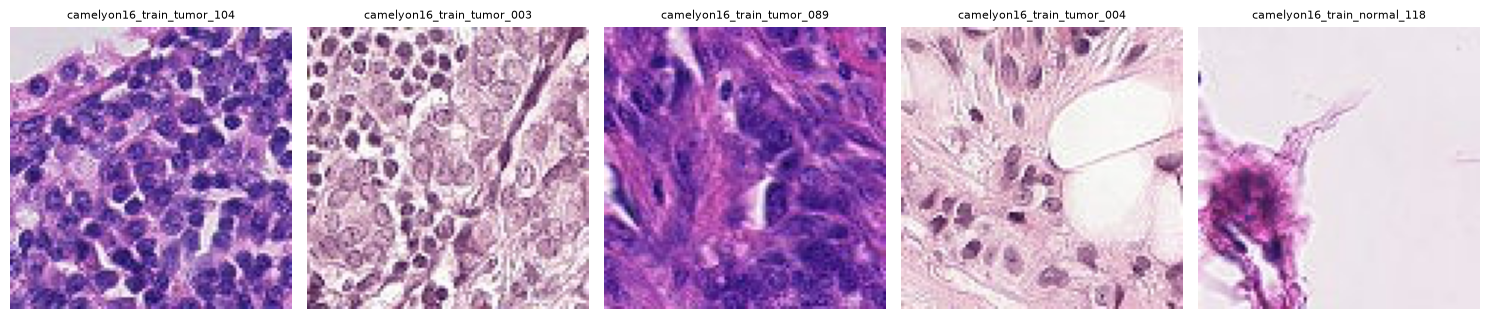

In [3]:
import pandas as pd

meta = pd.read_csv(DATA_DIR / "camelyonpatch_level_2_split_train_meta.csv")

# pick 5 different slides
sample_slides = meta["wsi"].unique()[:5]

fig, axes = plt.subplots(1, 5, figsize=(15, 4))

with h5py.File(DATA_DIR / "camelyonpatch_level_2_split_train_x.h5", "r") as f:
    images = f["x"]
    for col, slide_id in enumerate(sample_slides):
        # first patch belonging to this slide
        idx = meta[meta["wsi"] == slide_id].index[0]
        axes[col].imshow(images[idx])
        axes[col].set_title(slide_id, fontsize=8)
        axes[col].axis("off")

plt.tight_layout()
plt.savefig("../docs/stain_variation.png", dpi=100)
plt.show()